# Linear Autoencoder on Correlation Matrices
In this notebook we train a linear autoencoder (no non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [13]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Data
Load correlation matrices from a `.pt` file and optionally select a matrix range `[MATRIX_START, MATRIX_END)`.

In [14]:
MY_FILE_NAME = 'corr_windows_tensor_data_00_20_w724_s10.pt'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    processed_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    processed_dir = project_root / 'data' / 'processed'

selected_file = processed_dir / MY_FILE_NAME

if not selected_file.exists():
    raise FileNotFoundError(
        f"Errore: Il file '{MY_FILE_NAME}' non e stato trovato in: {processed_dir.absolute()}"
    )

print(f'File selezionato: {selected_file.name}')

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # number or None
MATRIX_END = None  # number or None, Example: 500 to use only the first 500 matrices
print(f'Matrix range: [{MATRIX_START}, {MATRIX_END})')

Ambiente rilevato: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File selezionato: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [15]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


corr_tensor, meta = load_corr_payload(selected_file)

orig_n = corr_tensor.shape[0]
start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_n if MATRIX_END is None else int(MATRIX_END)

if not (0 <= start_idx < end_idx <= orig_n):
    raise ValueError(f'Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_n}')

corr_tensor = corr_tensor[start_idx:end_idx]
if 'window_ranges' in meta and len(meta['window_ranges']) == orig_n:
    meta['window_ranges'] = meta['window_ranges'][start_idx:end_idx]

print(f'corr_tensor shape (selected range): {tuple(corr_tensor.shape)}')
print(f'using matrices: [{start_idx}, {end_idx}) out of {orig_n}')
print(f'dtype: {corr_tensor.dtype}')

corr_tensor shape (selected range): (412, 362, 362)
using matrices: [49, 461) out of 461
dtype: torch.float32


## Step 2: Prepare Matrices and Train/Validation/Test Split
Use full correlation matrices as input. For training, each matrix is flattened to a vector of size `N x N`.

In [16]:
SEED = 42
VAL_FRACTION = 0.2
TEST_FRACTION = 0.1

corr_np = corr_tensor.numpy().astype(np.float32)
n_matrices, n_assets, _ = corr_np.shape
n_features = n_assets * n_assets

X_flat = torch.from_numpy(corr_np.reshape(n_matrices, n_features))
rng = np.random.default_rng(SEED)
indices = np.arange(n_matrices)
rng.shuffle(indices)

n_val = max(1, int(n_matrices * VAL_FRACTION))
n_test = max(1, int(n_matrices * TEST_FRACTION))
n_train = n_matrices - n_val - n_test

if n_train <= 0:
    raise ValueError('Training split is empty. Reduce VAL_FRACTION/TEST_FRACTION or use more matrices.')

val_idx = indices[:n_val]
test_idx = indices[n_val:n_val + n_test]
train_idx = indices[n_val + n_test:]

x_train = X_flat[train_idx]
x_val = X_flat[val_idx]
x_test = X_flat[test_idx]

print(f'Number of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size: {n_features}')
print(f'Train size: {len(train_idx)} | Val size: {len(val_idx)} | Test size: {len(test_idx)}')

Number of matrices: 412
Matrix shape: (362, 362)
Flattened input size: 131044
Train size: 289 | Val size: 82 | Test size: 41


## Step 3: Define a Linear Autoencoder
The encoder and decoder are pure linear layers (no activation functions).

In [17]:
class LinearAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_linear_ae(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    step_size: int = 10,
    step_gamma: float = 0.5,
    plateau_factor: float = 0.5,
    plateau_patience: int = 5,
    plateau_threshold: float = 1e-3,
    plateau_min_lr: float = 1e-8,
    resume_state_dict=None,
    initial_best_val=None,
):

    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, criterion, scheduler
    model = LinearAutoencoder(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine', 'step', 'plateau'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max,
            eta_min=cosine_eta_min,
        )
    elif scheduler_key == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=step_size,
            gamma=step_gamma,
        )
    elif scheduler_key == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=plateau_factor,
            patience=plateau_patience,
            threshold=plateau_threshold,
            min_lr=plateau_min_lr,
        )

    # 3) DataLoaders
    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    # 4) Initialization of best validation loss
    if resume_state_dict is not None:
        if initial_best_val is None:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for (xb,) in val_loader:
                    xb = xb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, xb)
                    val_loss_sum += loss.item() * xb.size(0)
            initial_best_val = val_loss_sum / len(val_loader.dataset)

        best_val = float(initial_best_val)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_val = float('inf')
        best_state = None

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, xb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch + 1:>3}/{epochs} | lr={current_lr:.2e} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    # 6) Load best state and return
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_val


def reconstruct_matrices(model: nn.Module, x_tensor: torch.Tensor, n_assets: int, batch_size: int = 4):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            outputs.append(pred)

    recon_flat = np.concatenate(outputs, axis=0)
    recon = recon_flat.reshape(-1, n_assets, n_assets).astype(np.float32)

    # Enforce correlation-matrix structure after reconstruction.
    #recon = 0.5 * (recon + np.transpose(recon, (0, 2, 1)))
    #diag_idx = np.arange(n_assets)
    #recon[:, diag_idx, diag_idx] = 1.0

    return recon


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


## Step 5: Train One Configuration and Reconstruct Matrices
Train one linear AE configuration, reconstruct all matrices, and inspect training losses.

In [19]:
RUN = 'linearAE_0002'
RESUME_TRAINING = True
RESUME_MODEL_PATH = "best_models_tesi/linearAE/linearAE_0001/linear_AE_best_linearAE_0001.pt"  # Example: 'best_models_tesi/linearAE/<RUN>/linear_AE_best_<RUN>.pt'

if IS_COLAB:
    run_dir = Path('/content/drive/MyDrive/best_models_tesi/linearAE')
else:
    run_dir = project_root / 'models' / 'best_models_tesi' / 'linearAE'

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: /content/drive/MyDrive/best_models_tesi/linearAE/linearAE_0002
Resume training: True


Output streaming troncato alle ultime 5000 righe.
Epoch   6/5000 | lr=1.00e-05 | train_loss=0.009276 | val_loss=0.009621
Epoch   7/5000 | lr=1.00e-05 | train_loss=0.009272 | val_loss=0.009618
Epoch   8/5000 | lr=1.00e-05 | train_loss=0.009268 | val_loss=0.009615
Epoch   9/5000 | lr=1.00e-05 | train_loss=0.009266 | val_loss=0.009612
Epoch  10/5000 | lr=1.00e-05 | train_loss=0.009263 | val_loss=0.009609
Epoch  11/5000 | lr=1.00e-05 | train_loss=0.009260 | val_loss=0.009607
Epoch  12/5000 | lr=1.00e-05 | train_loss=0.009257 | val_loss=0.009607
Epoch  13/5000 | lr=1.00e-05 | train_loss=0.009255 | val_loss=0.009601
Epoch  14/5000 | lr=1.00e-05 | train_loss=0.009252 | val_loss=0.009598
Epoch  15/5000 | lr=1.00e-05 | train_loss=0.009249 | val_loss=0.009595
Epoch  16/5000 | lr=1.00e-05 | train_loss=0.009246 | val_loss=0.009593
Epoch  17/5000 | lr=1.00e-05 | train_loss=0.009244 | val_loss=0.009590
Epoch  18/5000 | lr=1.00e-05 | train_loss=0.009240 | val_loss=0.009587
Epoch  19/5000 | lr=1.00e-0

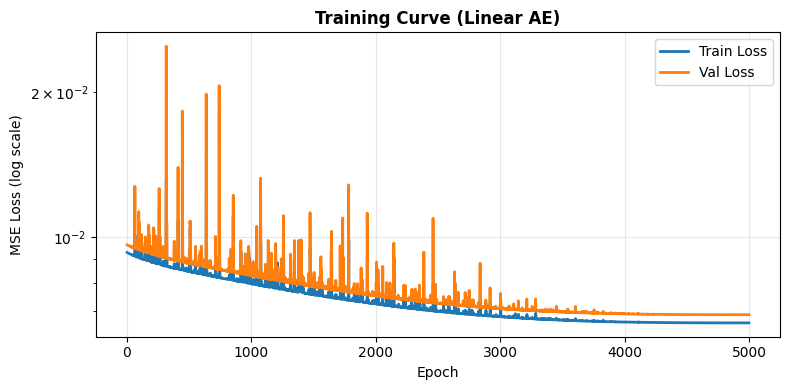

Saved training curve: /content/drive/MyDrive/best_models_tesi/linearAE/linearAE_0002/linear_AE_training_curve_linearAE_0002.png


In [20]:
LATENT_DIM = 3
EPOCHS = 5000
BATCH_SIZE = 16
LR = 1e-5
WEIGHT_DECAY = 0
# Scheduler selector: 'none', 'cosine', 'step', 'plateau'
SCHEDULER_NAME = 'cosine'

# 1) CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-8

# 2) StepLR params
STEP_SIZE = 10
STEP_GAMMA = 0.5

# 3) ReduceLROnPlateau params
PLATEAU_FACTOR = 0.5
PLATEAU_PATIENCE = 5
PLATEAU_THRESHOLD = 1e-3
PLATEAU_MIN_LR = 1e-8




resume_state_dict = None
resume_initial_val = None
resume_source_path = None
# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

    probe_model = LinearAutoencoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM)
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches:
        hint = ''
        if 'encoder.weight' in loaded_shapes:
            ckpt_latent_dim = loaded_shapes['encoder.weight'][0]
            ckpt_input_dim = loaded_shapes['encoder.weight'][1]
            hint = f'Checkpoint expects input_dim={ckpt_input_dim}, latent_dim={ckpt_latent_dim}.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current LinearAutoencoder. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        temp_model = LinearAutoencoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        criterion = nn.MSELoss()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = temp_model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation MSE (baseline for resume): {resume_initial_val:.6f}')







# Train the model (or resume training if applicable)
model, history, best_val = train_linear_ae(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    step_size=STEP_SIZE,
    step_gamma=STEP_GAMMA,
    plateau_factor=PLATEAU_FACTOR,
    plateau_patience=PLATEAU_PATIENCE,
    plateau_threshold=PLATEAU_THRESHOLD,
    plateau_min_lr=PLATEAU_MIN_LR,
    resume_state_dict=resume_state_dict,
    initial_best_val=resume_initial_val,
)




best_model_path = run_output_dir / f'linear_AE_best_{RUN}.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
)
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')

orig_corr = corr_np
recon_corr = reconstruct_matrices(model, X_flat, n_assets=n_assets)

print(f'Original tensor shape: {orig_corr.shape}')
print(f'Reconstructed tensor shape: {recon_corr.shape}')
print(f'Latent dimension: {LATENT_DIM}')

fig, ax = plt.subplots(figsize=(8, 4))
epochs_to_plot = list(range(5, EPOCHS))
ax.plot(epochs_to_plot, history['train_loss'][5:], label='Train Loss', linewidth=2)
ax.plot(epochs_to_plot, history['val_loss'][5:], label='Val Loss', linewidth=2)
ax.set_title('Training Curve (Linear AE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_yscale('log')
ax.set_ylabel('MSE Loss (log scale)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

train_curve_path = run_output_dir / f'linear_AE_training_curve_{RUN}.png'
fig.savefig(train_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved training curve: {train_curve_path}')

## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Original Matrix:
[[1.     0.3999 0.3217 0.3456 0.4316]
 [0.3999 1.     0.3521 0.4409 0.4306]
 [0.3217 0.3521 1.     0.3798 0.382 ]
 [0.3456 0.4409 0.3798 1.     0.3974]
 [0.4316 0.4306 0.382  0.3974 1.    ]]
Reconstructed Matrix:
[[1.1713 0.3047 0.2689 0.2973 0.5294]
 [0.3003 1.2521 0.26   0.4788 0.4731]
 [0.3283 0.2517 1.1203 0.2417 0.3101]
 [0.3006 0.4505 0.3072 1.0802 0.3224]
 [0.5063 0.384  0.3473 0.4144 1.1865]]
Error Matrix:
[[ 0.1713 -0.0952 -0.0528 -0.0484  0.0979]
 [-0.0996  0.2521 -0.0921  0.0379  0.0425]
 [ 0.0066 -0.1004  0.1203 -0.1381 -0.0719]
 [-0.045   0.0095 -0.0727  0.0802 -0.075 ]
 [ 0.0747 -0.0467 -0.0348  0.017   0.1865]]
Sample index: 200
MSE: 0.005224 | MAE: 0.056001 | Frobenius: 26.165215
Error range - Min: -0.337623 | Max: 0.413219


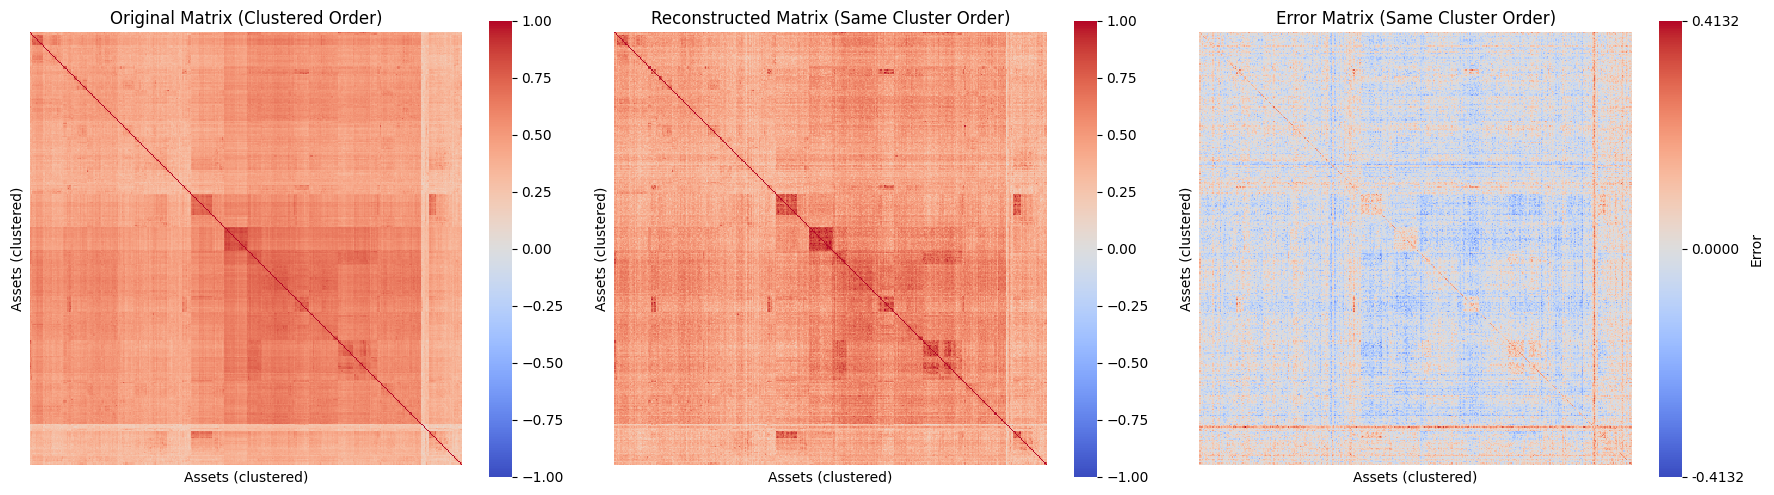

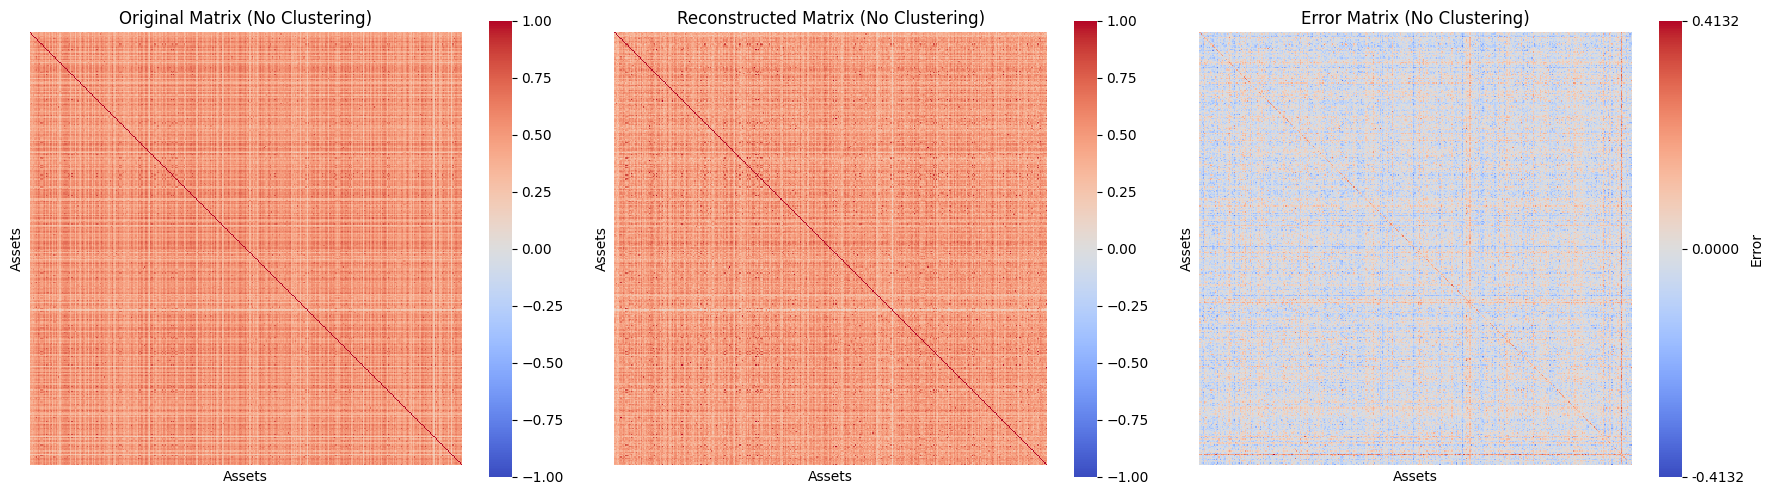

Saved heatmaps for matrix index 200:
 - /content/drive/MyDrive/best_models_tesi/linearAE/linearAE_0002/heatmaps/idx200/linear_AE_clustered_heatmaps.png
 - /content/drive/MyDrive/best_models_tesi/linearAE/linearAE_0002/heatmaps/idx200/linear_AE_standard_heatmaps.png


In [21]:
SAMPLE_IDX = 200

if not (0 <= SAMPLE_IDX < orig_corr.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {orig_corr.shape[0] - 1}]')

orig_mat = orig_corr[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_all = heatmap_dir / 'linear_AE_clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_all, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_standard = heatmap_dir / 'linear_AE_standard_heatmaps.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster_all}')
print(f' - {path_standard}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on the test set (MSE, MAE, Frobenius norm).

In [22]:
# Compute error statistics on test set only
orig_corr_test = corr_np[test_idx]
recon_corr_test = recon_corr[test_idx]

errors_df, errors_stats = reconstruction_errors(orig_corr_test, recon_corr_test)

print('Reconstruction error statistics (Test Set):')
display(errors_stats)

Reconstruction error statistics (Test Set):


,mean,std,min,median,max
MSE,0.006848,0.001900,0.004382,0.006559,0.011297
MAE,0.063754,0.008462,0.052154,0.063231,0.082319
Frobenius,29.693363,4.008833,23.962887,29.318544,38.476364


In [23]:
results_path = run_output_dir / f'linear_AE_results_{RUN}.json'

recon_stats_payload = None
if 'errors_stats' in globals():
    recon_stats_payload = errors_stats.astype(float).to_dict()

scheduler_key = str(SCHEDULER_NAME).strip().lower()
scheduler_label_map = {
    'none': None,
    'cosine': 'CosineAnnealingLR',
    'step': 'StepLR',
    'plateau': 'ReduceLROnPlateau',
}

scheduler_payload = {
    'key': scheduler_key,
    'type': scheduler_label_map.get(scheduler_key, 'Unknown'),
    'enabled': scheduler_key != 'none',
}

if scheduler_key == 'cosine':
    scheduler_payload.update({
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    })
elif scheduler_key == 'step':
    scheduler_payload.update({
        'step_size': int(STEP_SIZE),
        'gamma': float(STEP_GAMMA),
    })
elif scheduler_key == 'plateau':
    scheduler_payload.update({
        'factor': float(PLATEAU_FACTOR),
        'patience': int(PLATEAU_PATIENCE),
        'threshold': float(PLATEAU_THRESHOLD),
        'min_lr': float(PLATEAU_MIN_LR),
    })

results_payload = {
    'run': RUN,
    'selected_file': str(selected_file),
    'matrix_range': {
        'start_idx': int(start_idx),
        'end_idx': int(end_idx),
    },
    'data': {
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(len(train_idx)),
            'val_size': int(len(val_idx)),
            'test_size': int(len(test_idx)),
            'val_fraction': float(VAL_FRACTION),
            'test_fraction': float(TEST_FRACTION),
        },
    },
    'model': {
        'latent_dim': int(LATENT_DIM),
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'seed': int(SEED),
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': {
            'enabled': bool(RESUME_TRAINING),
            'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
            'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
        },
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(train_curve_path) if 'train_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats_test': recon_stats_payload,
    },
    'loss_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

Saved results: /content/drive/MyDrive/best_models_tesi/linearAE/linearAE_0002/linear_AE_results_linearAE_0002.json
